In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
# ── Cell 1: Install ───────────────────────────────────────
!pip install textstat transformers datasets scikit-learn torch -q

In [10]:
# ── Cell 2: Imports ───────────────────────────────────────
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import textstat
import pickle
import random
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
label2id = {"elementary": 0, "middle": 1, "high": 2}
id2label = {0: "elementary", 1: "middle", 2: "high"}
random.seed(42)
np.random.seed(42)

Using device: cuda


In [11]:
# ── Cell 3: Load ScienceQA + OSE ─────────────────────────
print("Loading ScienceQA...")
dataset = load_dataset("nlpscu/Beyond-Flesch", "texts")
scienceqa_train_texts = list(dataset["train"]["full_text"])
scienceqa_train_labels = list(dataset["train"]["education_level"])
scienceqa_test_texts = list(dataset["test"]["full_text"])
scienceqa_test_labels = list(dataset["test"]["education_level"])
print(f"✅ ScienceQA: {len(scienceqa_train_texts)} train")

print("Loading OneStopEnglish...")
ose = load_dataset("onestop_english")
ose_texts = list(ose["train"]["text"])
ose_raw_labels = list(ose["train"]["label"])
label_map_ose = {0: "elementary", 1: "middle", 2: "high"}
ose_labels = [label_map_ose[int(l)] for l in ose_raw_labels]
ose_train_texts, ose_test_texts, ose_train_labels, ose_test_labels = train_test_split(
    ose_texts, ose_labels, test_size=0.2, random_state=42, stratify=ose_labels
)
print(f"✅ OSE: {len(ose_train_texts)} train")

Loading ScienceQA...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/13.8M [00:00<?, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3638 [00:00<?, ? examples/s]

...

✅ ScienceQA: 3638 train
Loading OneStopEnglish...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/567 [00:00<?, ? examples/s]

✅ OSE: 453 train


In [12]:
# ── Cell 4: Load RACE (balanced) ─────────────────────────
print("Loading RACE...")
race_middle = load_dataset("race", "middle")
race_high = load_dataset("race", "high")

# Balance RACE — sample equal amounts matching ScienceQA size
TARGET = len(scienceqa_train_texts)  # 3638

race_middle_texts = list(race_middle["train"]["article"])
race_high_texts = list(race_high["train"]["article"])
race_test_texts = list(race_middle["test"]["article"]) + list(race_high["test"]["article"])
race_test_labels = ["middle"] * len(race_middle["test"]) + ["high"] * len(race_high["test"])

# Sample balanced
random.shuffle(race_middle_texts)
random.shuffle(race_high_texts)
race_middle_sampled = race_middle_texts[:TARGET]
race_high_sampled = race_high_texts[:TARGET]

race_train_texts = race_middle_sampled + race_high_sampled
race_train_labels = ["middle"] * len(race_middle_sampled) + ["high"] * len(race_high_sampled)

print(f"✅ RACE train — middle: {len(race_middle_sampled)}, high: {len(race_high_sampled)}")
print(f"✅ RACE test: {len(race_test_texts)}")

Loading RACE...


README.md: 0.00B [00:00, ?B/s]

middle/test-00000-of-00001.parquet:   0%|          | 0.00/405k [00:00<?, ?B/s]

middle/train-00000-of-00001.parquet:   0%|          | 0.00/6.97M [00:00<?, ?B/s]

middle/validation-00000-of-00001.parquet:   0%|          | 0.00/407k [00:00<?, ?B/s]

...

high/validation-00000-of-00001.parquet:   0%|          | 0.00/1.66M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/3498 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/62445 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3451 [00:00<?, ? examples/s]

✅ RACE train — middle: 3638, high: 3638
✅ RACE test: 4934


In [13]:
# ── Cell 5: Load Wikipedia (streaming) ───────────────────
print("Loading Simple English Wikipedia (streaming)...")
simple_wiki = load_dataset("wikimedia/wikipedia", "20231101.simple", streaming=True)
simple_train = []
simple_test = []
for i, x in enumerate(simple_wiki["train"]):
    if len(x["text"]) > 200:
        if len(simple_train) < TARGET:
            simple_train.append(x["text"])
        elif len(simple_test) < 300:
            simple_test.append(x["text"])
    if len(simple_train) >= TARGET and len(simple_test) >= 300:
        break
print(f"✅ Simple Wiki train: {len(simple_train)} | test: {len(simple_test)}")

print("Loading Regular English Wikipedia (streaming)...")
reg_wiki = load_dataset("wikimedia/wikipedia", "20231101.en", streaming=True)
reg_train = []
reg_test = []
for x in reg_wiki["train"]:
    if len(x["text"]) > 200:
        if len(reg_train) < TARGET:
            reg_train.append(x["text"])
        elif len(reg_test) < 300:
            reg_test.append(x["text"])
    if len(reg_train) >= TARGET and len(reg_test) >= 300:
        break
print(f"✅ Regular Wiki train: {len(reg_train)} | test: {len(reg_test)}")

# Wikipedia OOD test set (never seen during training)
wiki_test_texts = simple_test + reg_test
wiki_test_labels = ["elementary"] * len(simple_test) + ["high"] * len(reg_test)
wiki_test_ids = [label2id[l] for l in wiki_test_labels]
print(f"✅ Wikipedia OOD test: {len(wiki_test_texts)}")

Loading Simple English Wikipedia (streaming)...


README.md: 0.00B [00:00, ?B/s]

✅ Simple Wiki train: 3638 | test: 300
Loading Regular English Wikipedia (streaming)...


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

✅ Regular Wiki train: 3638 | test: 300
✅ Wikipedia OOD test: 600


In [16]:
# ── Cell 6: Combine ALL training data (balanced) ──────────
combined_texts = (
    scienceqa_train_texts +   # elem/mid/high
    ose_train_texts +         # elem/mid/high
    race_train_texts +        # mid/high (balanced)
    simple_train +            # elementary (wiki)
    reg_train                 # high (wiki)
)

combined_labels = (
    [label2id[l] for l in scienceqa_train_labels] +
    [label2id[l] for l in ose_train_labels] +
    [label2id[l] for l in race_train_labels] +
    [label2id["elementary"]] * len(simple_train) +
    [label2id["high"]] * len(reg_train)
)

scienceqa_test_ids = [label2id[l] for l in scienceqa_test_labels]
race_test_ids = [label2id[l] for l in race_test_labels]

# Check class balance
from collections import Counter
counts = Counter(combined_labels)
print(f"\nClass distribution in training:")
for k, v in counts.items():
    print(f"  {id2label[k]}: {v}")
print(f"Total train: {len(combined_texts)}")


Class distribution in training:
  high: 8640
  elementary: 5002
  middle: 5001
Total train: 18643


In [17]:
# ── Cell 7: Static Features ───────────────────────────────
def compute_static_features(texts):
    features = []
    for text in texts:
        if not text or len(text.strip()) == 0:
            features.append([0.0] * 10)
            continue
        try:
            f = [
                textstat.flesch_reading_ease(text),
                textstat.flesch_kincaid_grade(text),
                textstat.gunning_fog(text),
                textstat.smog_index(text),
                textstat.coleman_liau_index(text),
                textstat.automated_readability_index(text),
                textstat.dale_chall_readability_score(text),
                textstat.avg_sentence_length(text),
                textstat.avg_syllables_per_word(text),
                textstat.lexicon_count(text, removepunct=True) / max(textstat.sentence_count(text), 1)
            ]
        except:
            f = [0.0] * 10
        features.append(f)
    return np.array(features, dtype=np.float32)

print("Computing train static features (~15 mins)...")
train_static = compute_static_features(combined_texts)
print("Computing ScienceQA test...")
scienceqa_static = compute_static_features(scienceqa_test_texts)
print("Computing RACE test...")
race_static = compute_static_features(race_test_texts)
print("Computing Wikipedia OOD test...")
wiki_static = compute_static_features(wiki_test_texts)

# Clean
for arr in [train_static, scienceqa_static, race_static, wiki_static]:
    np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0, copy=False)

# Scale
scaler = StandardScaler()
train_static_scaled = scaler.fit_transform(train_static)
scienceqa_static_scaled = scaler.transform(scienceqa_static)
race_static_scaled = scaler.transform(race_static)
wiki_static_scaled = scaler.transform(wiki_static)
print("✅ Static features done!")

Computing train static features (~15 mins)...


/tmp/ipykernel_57/1500332092.py:17: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  textstat.avg_sentence_length(text),


Computing ScienceQA test...
Computing RACE test...
Computing Wikipedia OOD test...
✅ Static features done!


In [18]:
# ── Cell 8: Model + Dataset Classes ──────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, labels, static_features, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.static = torch.tensor(static_features, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "static": self.static[idx],
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

class BERTWithStatic(nn.Module):
    def __init__(self, model_name, static_dim=10, num_classes=3, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.static_proj = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, static_features):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls = outputs.last_hidden_state[:, 0, :]
        static_out = self.static_proj(static_features)
        combined = torch.cat([cls, static_out], dim=1)
        return self.classifier(combined)

MODEL_NAME = "bert-base-uncased"
print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = BERTWithStatic(MODEL_NAME).to(device)
print("✅ Model ready!")

Loading bert-base-uncased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model ready!


In [20]:
# ── Cell 9: Dataloaders ───────────────────────────────────
train_dataset = TextDataset(combined_texts, combined_labels, train_static_scaled, tokenizer)
scienceqa_test_dataset = TextDataset(scienceqa_test_texts, scienceqa_test_ids, scienceqa_static_scaled, tokenizer)
race_test_dataset = TextDataset(race_test_texts, race_test_ids, race_static_scaled, tokenizer)
wiki_test_dataset = TextDataset(wiki_test_texts, wiki_test_ids, wiki_static_scaled, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
scienceqa_test_loader = DataLoader(scienceqa_test_dataset, batch_size=32)
race_test_loader = DataLoader(race_test_dataset, batch_size=32)
wiki_test_loader = DataLoader(wiki_test_dataset, batch_size=32)
print(f"✅ Train batches: {len(train_loader)}")

✅ Train batches: 1166


In [21]:
# ── Cell 10: Train with Gradual Unfreezing ────────────────
criterion = nn.CrossEntropyLoss()

# Phase 1 — Freeze BERT, train only classifier (2 epochs)
print("Phase 1 — Training classifier only (BERT frozen)...")
for param in model.encoder.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

for epoch in range(2):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        static = batch["static"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, static)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        if i % 200 == 0:
            print(f"  Phase1 Epoch {epoch+1} | Step {i}/{len(train_loader)} | Loss: {loss.item():.4f}")
    print(f"Phase1 Epoch {epoch+1} — Avg Loss: {total_loss/len(train_loader):.4f}")

# Phase 2 — Unfreeze BERT, fine-tune everything (3 epochs)
print("\nPhase 2 — Fine-tuning all layers (BERT unfrozen)...")
for param in model.encoder.parameters():
    param.requires_grad = True

total_steps = len(train_loader) * 3
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

for epoch in range(3):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        static = batch["static"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, static)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if i % 200 == 0:
            print(f"  Phase2 Epoch {epoch+1} | Step {i}/{len(train_loader)} | Loss: {loss.item():.4f}")
    print(f"Phase2 Epoch {epoch+1} — Avg Loss: {total_loss/len(train_loader):.4f}")

Phase 1 — Training classifier only (BERT frozen)...
  Phase1 Epoch 1 | Step 0/1166 | Loss: 1.0993
  Phase1 Epoch 1 | Step 200/1166 | Loss: 0.8459
  Phase1 Epoch 1 | Step 400/1166 | Loss: 0.3042
  Phase1 Epoch 1 | Step 600/1166 | Loss: 0.4919
  Phase1 Epoch 1 | Step 800/1166 | Loss: 0.6285
  Phase1 Epoch 1 | Step 1000/1166 | Loss: 0.3176
Phase1 Epoch 1 — Avg Loss: 0.4869
  Phase1 Epoch 2 | Step 0/1166 | Loss: 0.3863
  Phase1 Epoch 2 | Step 200/1166 | Loss: 0.4794
  Phase1 Epoch 2 | Step 400/1166 | Loss: 0.5098
  Phase1 Epoch 2 | Step 600/1166 | Loss: 0.2203
  Phase1 Epoch 2 | Step 800/1166 | Loss: 0.5350
  Phase1 Epoch 2 | Step 1000/1166 | Loss: 0.2765
Phase1 Epoch 2 — Avg Loss: 0.3876

Phase 2 — Fine-tuning all layers (BERT unfrozen)...
  Phase2 Epoch 1 | Step 0/1166 | Loss: 0.1576
  Phase2 Epoch 1 | Step 200/1166 | Loss: 0.1112
  Phase2 Epoch 1 | Step 400/1166 | Loss: 0.4881
  Phase2 Epoch 1 | Step 600/1166 | Loss: 0.6699
  Phase2 Epoch 1 | Step 800/1166 | Loss: 0.0367
  Phase2 Epoch 

In [22]:
# ── Cell 11: Save ─────────────────────────────────────────
save_dir = "/kaggle/working/bert_static_model_v2"
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), f"{save_dir}/model_weights.pt")
tokenizer.save_pretrained(save_dir)
with open(f"{save_dir}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print(f"✅ Model saved to {save_dir}")

✅ Model saved to /kaggle/working/bert_static_model_v2


In [23]:
# After training completes, create a Kaggle dataset
import os
os.makedirs("/kaggle/working/bert_static_model_v2", exist_ok=True)

# Save model (already doing this)
torch.save(model.state_dict(), "/kaggle/working/bert_static_model_v2/model_weights.pt")
tokenizer.save_pretrained("/kaggle/working/bert_static_model_v2")
with open("/kaggle/working/bert_static_model_v2/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Saved!")

✅ Saved!


In [24]:
import zipfile
import os

# Zip the model
zip_path = "/kaggle/working/bert_static_model_v2.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir("/kaggle/working/bert_static_model_v2"):
        zipf.write(
            f"/kaggle/working/bert_static_model_v2/{file}",
            file
        )

size = os.path.getsize(zip_path) / 1024 / 1024
print(f"✅ Zipped: {size:.1f} MB")

✅ Zipped: 387.8 MB


In [12]:
# ── Cell 12: Evaluate ─────────────────────────────────────
def evaluate(model, loader, true_ids, label_filter=None):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            static = batch["static"].to(device)
            outputs = model(input_ids, attention_mask, static)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
    pred_labels = [id2label[p] for p in all_preds]
    true_labels = [id2label[t] for t in true_ids]
    if label_filter:
        print(classification_report(true_labels, pred_labels,
              labels=label_filter, zero_division=0))
        return f1_score(true_labels, pred_labels,
               labels=label_filter, average="macro", zero_division=0)
    else:
        print(classification_report(true_labels, pred_labels, zero_division=0))
        return f1_score(true_labels, pred_labels, average="macro", zero_division=0)

print("\n=== ScienceQA Test ===")
scienceqa_f1 = evaluate(model, scienceqa_test_loader, scienceqa_test_ids)
print(f"ScienceQA Macro-F1: {scienceqa_f1:.4f}")

print("\n=== RACE Test ===")
race_f1 = evaluate(model, race_test_loader, race_test_ids,
                   label_filter=["middle", "high"])
print(f"RACE Macro-F1: {race_f1:.4f}")

print("\n=== Wikipedia OOD (True Unseen Test) ===")
wiki_f1 = evaluate(model, wiki_test_loader, wiki_test_ids,
                   label_filter=["elementary", "high"])
print(f"Wikipedia OOD Macro-F1: {wiki_f1:.4f}")

print("\n=== FINAL SUMMARY ===")
print(f"{'Model':<45} {'ScienceQA':>10} {'RACE':>8} {'Wiki(OOD)':>10}")
print(f"{'LR COMBO (Rooein baseline)':<45} {'0.8416':>10} {'N/A':>8} {'N/A':>10}")
print(f"{'TF-IDF (ScienceQA only)':<45} {'0.9058':>10} {'0.0102':>8} {'N/A':>10}")
print(f"{'TF-IDF (ScienceQA+OSE)':<45} {'0.9069':>10} {'0.2169':>8} {'N/A':>10}")
print(f"{'BERT+Static v1 (3 domains)':<45} {'0.8950':>10} {'0.8387':>8} {'0.4186':>10}")
print(f"{'BERT+Static v2 (balanced+wiki)':<45} {scienceqa_f1:>10.4f} {race_f1:>10.4f} {wiki_f1:>10.4f}")


=== ScienceQA Test ===
              precision    recall  f1-score   support

  elementary       0.97      0.93      0.95       303
        high       0.90      0.88      0.89       303
      middle       0.83      0.89      0.86       304

    accuracy                           0.90       910
   macro avg       0.90      0.90      0.90       910
weighted avg       0.90      0.90      0.90       910

ScienceQA Macro-F1: 0.8987

=== RACE Test ===
              precision    recall  f1-score   support

      middle       0.65      0.87      0.74      1436
        high       0.94      0.80      0.87      3498

   micro avg       0.83      0.82      0.82      4934
   macro avg       0.80      0.84      0.80      4934
weighted avg       0.86      0.82      0.83      4934

RACE Macro-F1: 0.8049

=== Wikipedia OOD (True Unseen Test) ===
              precision    recall  f1-score   support

  elementary       0.95      0.97      0.96       300
        high       0.97      0.95      0.96      

In [13]:
from datasets import load_dataset

to_try = [
    "CommonLit/commonlit-readability-prize",
    "commonlit",
    "commonlit_readability",
    "tasksource/commonlit-readability-prize",
    "crew/commonlit",
    "danielsamuels/commonlit-readability",
]

for name in to_try:
    try:
        d = load_dataset(name)
        print(f"✅ {name}")
        print(d[list(d.keys())[0]][0])
        break
    except Exception as e:
        print(f"❌ {name} — {str(e)[:60]}")

❌ CommonLit/commonlit-readability-prize — Dataset 'CommonLit/commonlit-readability-prize' doesn't exis
❌ commonlit — Dataset 'commonlit' doesn't exist on the Hub or cannot be ac
❌ commonlit_readability — Dataset 'commonlit_readability' doesn't exist on the Hub or 
❌ tasksource/commonlit-readability-prize — Dataset 'tasksource/commonlit-readability-prize' doesn't exi
❌ crew/commonlit — Dataset 'crew/commonlit' doesn't exist on the Hub or cannot 
❌ danielsamuels/commonlit-readability — Dataset 'danielsamuels/commonlit-readability' doesn't exist 


Target stats:
count    2834.000000
mean       -0.959319
std         1.033579
min        -3.676268
25%        -1.690320
50%        -0.912190
75%        -0.202540
max         1.711390
Name: target, dtype: float64

Min: -3.676
Max: 1.711


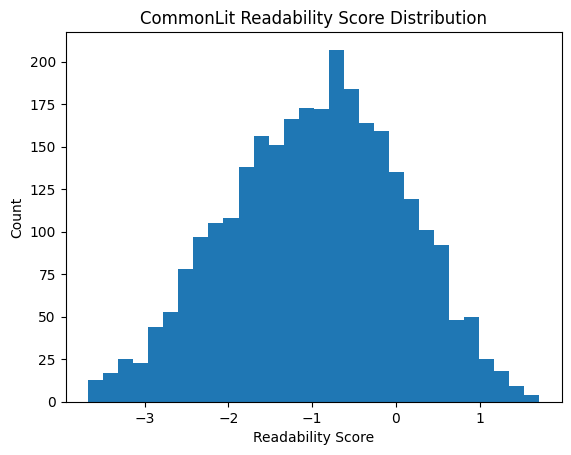


Class distribution after bucketing:
grade_level
middle        964
elementary    935
high          935
Name: count, dtype: int64

Sample texts per class:

elementary: Hal Paine and Chester Crawford were typical American boys. With the former's mother, they had been in Berlin when the great European conflagration bro

middle: As Roger had predicted, the snow departed as quickly as it came, and two days after their sleigh ride there was scarcely a vestige of white on the gro

high: When the young people returned to the ballroom, it presented a decidedly changed appearance. Instead of an interior scene, it was a winter landscape.



In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "/kaggle/input/competitions/commonlitreadabilityprize"
df = pd.read_csv(f"{path}/train.csv")

print("Target stats:")
print(df["target"].describe())
print(f"\nMin: {df['target'].min():.3f}")
print(f"Max: {df['target'].max():.3f}")

# Plot distribution
plt.hist(df["target"], bins=30)
plt.xlabel("Readability Score")
plt.ylabel("Count")
plt.title("CommonLit Readability Score Distribution")
plt.show()

# Bucket into 3 classes using percentiles
df["grade_level"] = pd.cut(
    df["target"],
    bins=[df["target"].min()-0.01,
          df["target"].quantile(0.33),
          df["target"].quantile(0.67),
          df["target"].max()+0.01],
    labels=["elementary", "middle", "high"]
)

print("\nClass distribution after bucketing:")
print(df["grade_level"].value_counts())
print("\nSample texts per class:")
for level in ["elementary", "middle", "high"]:
    sample = df[df["grade_level"]==level]["excerpt"].iloc[0]
    print(f"\n{level}: {sample[:150]}")

In [23]:
import pandas as pd
import numpy as np

path = "/kaggle/input/competitions/commonlitreadabilityprize"
df = pd.read_csv(f"{path}/train.csv")

# Bucket into 3 classes
df["grade_level"] = pd.cut(
    df["target"],
    bins=[df["target"].min()-0.01,
          df["target"].quantile(0.33),
          df["target"].quantile(0.67),
          df["target"].max()+0.01],
    labels=["elementary", "middle", "high"]
)

# Get texts and labels
commonlit_texts = list(df["excerpt"])
commonlit_labels = list(df["grade_level"].astype(str))
commonlit_ids = [label2id[l] for l in commonlit_labels]

print(f"CommonLit samples: {len(commonlit_texts)}")
print(f"Class distribution: {dict(df['grade_level'].value_counts())}")

# Compute static features
print("\nComputing static features for CommonLit...")
commonlit_static = compute_static_features(commonlit_texts)
commonlit_static = np.nan_to_num(commonlit_static, nan=0.0, posinf=0.0, neginf=0.0)
commonlit_static_scaled = scaler.transform(commonlit_static)

# Create dataloader
from torch.utils.data import DataLoader
commonlit_dataset = TextDataset(
    commonlit_texts, commonlit_ids,
    commonlit_static_scaled, tokenizer
)
commonlit_loader = DataLoader(commonlit_dataset, batch_size=32)

# Evaluate
print("\n=== CommonLit OOD (True Unseen Domain) ===")
commonlit_f1 = evaluate(model, commonlit_loader, commonlit_ids)
print(f"CommonLit Macro-F1: {commonlit_f1:.4f}")

# Final summary
print("\n=== FINAL SUMMARY ===")
print(f"{'Model':<45} {'ScienceQA':>10} {'RACE':>8} {'CommonLit(OOD)':>15}")
print(f"{'LR COMBO (Rooein baseline)':<45} {'0.8416':>10} {'N/A':>8} {'N/A':>15}")
print(f"{'TF-IDF (ScienceQA only)':<45} {'0.9058':>10} {'0.0102':>8} {'N/A':>15}")
print(f"{'TF-IDF (ScienceQA+OSE)':<45} {'0.9069':>10} {'0.2169':>8} {'N/A':>15}")
print(f"{'BERT+Static v1 (3 domains)':<45} {'0.8950':>10} {'0.8387':>8} {'N/A':>15}")
print(f"{'BERT+Static v2 (balanced+wiki)':<45} {'0.8987':>10} {'0.8049':>8} {commonlit_f1:>15.4f}")

CommonLit samples: 2834
Class distribution: {'middle': np.int64(964), 'elementary': np.int64(935), 'high': np.int64(935)}

Computing static features for CommonLit...


/tmp/ipykernel_57/1500332092.py:17: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  textstat.avg_sentence_length(text),



=== CommonLit OOD (True Unseen Domain) ===
              precision    recall  f1-score   support

  elementary       0.20      0.05      0.08       935
        high       0.25      0.61      0.36       935
      middle       0.18      0.07      0.10       964

    accuracy                           0.24      2834
   macro avg       0.21      0.24      0.18      2834
weighted avg       0.21      0.24      0.18      2834

CommonLit Macro-F1: 0.1785

=== FINAL SUMMARY ===
Model                                          ScienceQA     RACE  CommonLit(OOD)
LR COMBO (Rooein baseline)                        0.8416      N/A             N/A
TF-IDF (ScienceQA only)                           0.9058   0.0102             N/A
TF-IDF (ScienceQA+OSE)                            0.9069   0.2169             N/A
BERT+Static v1 (3 domains)                        0.8950   0.8387             N/A
BERT+Static v2 (balanced+wiki)                    0.8987   0.8049          0.1785


In [24]:
from datasets import load_dataset

to_try = [
    ("roneneldan/TinyStories", None),
    ("ajibawa-2023/children-stories-collection", None),
    ("maarcelbittencourt/children-stories", None),
    ("stories", None),
    ("mickume/harry_potter_books", None),
    ("dziemian/story-generation", None),
    ("Fraser/news-category-dataset", None),
    ("scientific_papers", "arxiv"),
    ("ccdv/arxiv-classification", None),
    ("ccdv/cnn-dailymail", "3.0.0"),
    ("ccdv/pubmed-summarization", None),
    ("khalidalt/DailyMail-v1", None),
    ("SophieTr/childrens-book", None),
    ("google-research-datasets/mbpp", None),
    ("adamzinebi/short-story-for-kids", None),
    ("chillies/kids-story", None),
    ("short_jokes", None),
    ("mc4", "en"),
]

for name, config in to_try:
    try:
        if config:
            d = load_dataset(name, config, streaming=True)
        else:
            d = load_dataset(name, streaming=True)
        # just get first sample
        first = next(iter(d[list(d.keys())[0]]))
        print(f"✅ {name} ({config})")
        print(f"   Keys: {list(first.keys())}")
        print(f"   Sample: {str(first)[:150]}")
        print("---")
    except Exception as e:
        print(f"❌ {name} — {str(e)[:60]}")

README.md: 0.00B [00:00, ?B/s]

✅ roneneldan/TinyStories (None)
   Keys: ['text']
   Sample: {'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to
---


README.md:   0%|          | 0.00/625 [00:00<?, ?B/s]

✅ ajibawa-2023/children-stories-collection (None)
   Keys: ['text', 'prompt', 'text_token_length']
   Sample: {'text': ' Once upon a time in the land of Policymia, there lived two leaders named Majora and Minoro. Their job was to make sure all the citizens had
---
❌ maarcelbittencourt/children-stories — Dataset 'maarcelbittencourt/children-stories' doesn't exist 
❌ stories — Dataset 'stories' doesn't exist on the Hub or cannot be acce
❌ mickume/harry_potter_books — Dataset 'mickume/harry_potter_books' doesn't exist on the Hu
❌ dziemian/story-generation — Dataset 'dziemian/story-generation' doesn't exist on the Hub
❌ Fraser/news-category-dataset — Dataset 'Fraser/news-category-dataset' doesn't exist on the 


README.md: 0.00B [00:00, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

✅ google-research-datasets/mbpp (None)
   Keys: ['task_id', 'text', 'code', 'test_list', 'test_setup_code', 'challenge_test_list']
   Sample: {'task_id': 601, 'text': 'Write a function to find the longest chain which can be formed from the given set of pairs.', 'code': 'class Pair(object): \
---
❌ adamzinebi/short-story-for-kids — Dataset 'adamzinebi/short-story-for-kids' doesn't exist on t
❌ chillies/kids-story — Dataset 'chillies/kids-story' doesn't exist on the Hub or ca
❌ short_jokes — Dataset 'short_jokes' doesn't exist on the Hub or cannot be 


README.md: 0.00B [00:00, ?B/s]

mc4.py: 0.00B [00:00, ?B/s]

❌ mc4 — Dataset scripts are no longer supported, but found mc4.py


In [25]:
from datasets import load_dataset
import random
random.seed(42)

# ── Elementary: TinyStories ───────────────────────────────
print("Loading TinyStories (elementary)...")
tiny = load_dataset("roneneldan/TinyStories", streaming=True)
elementary_texts = []
for x in tiny["train"]:
    if len(x["text"]) > 100:
        elementary_texts.append(x["text"])
    if len(elementary_texts) == 400:
        break
print(f"✅ TinyStories: {len(elementary_texts)} samples")
print(f"Sample: {elementary_texts[0][:150]}")

# ── High: ArXiv papers ────────────────────────────────────
print("\nLoading ArXiv (high)...")
arxiv = load_dataset("ccdv/arxiv-classification", streaming=True)
high_texts = []
for x in arxiv["train"]:
    if len(x["text"]) > 100:
        high_texts.append(x["text"])
    if len(high_texts) == 400:
        break
print(f"✅ ArXiv: {len(high_texts)} samples")
print(f"Sample: {high_texts[0][:150]}")

# ── Middle: PubMed abstracts ──────────────────────────────
print("\nLoading PubMed (middle)...")
pubmed = load_dataset("ccdv/pubmed-summarization", streaming=True)
middle_texts = []
for x in pubmed["train"]:
    text = x["abstract"]
    if len(text) > 100:
        middle_texts.append(text)
    if len(middle_texts) == 400:
        break
print(f"✅ PubMed: {len(middle_texts)} samples")
print(f"Sample: {middle_texts[0][:150]}")

# ── Combine ───────────────────────────────────────────────
ood_texts = elementary_texts + middle_texts + high_texts
ood_labels = (
    ["elementary"] * len(elementary_texts) +
    ["middle"] * len(middle_texts) +
    ["high"] * len(high_texts)
)
ood_ids = [label2id[l] for l in ood_labels]

print(f"\nTotal OOD samples: {len(ood_texts)}")
print(f"elementary: {len(elementary_texts)}")
print(f"middle: {len(middle_texts)}")
print(f"high: {len(high_texts)}")

Loading TinyStories (elementary)...
✅ TinyStories: 400 samples
Sample: One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the

Loading ArXiv (high)...
✅ ArXiv: 400 samples
Sample: Constrained Submodular Maximization via a
Non-symmetric Technique

arXiv:1611.03253v1 [cs.DS] 10 Nov 2016

Niv Buchbinder∗

Moran Feldman†

November 1

Loading PubMed (middle)...
✅ PubMed: 400 samples
Sample: background : the present study was carried out to assess the effects of community nutrition intervention based on advocacy approach on malnutrition st

Total OOD samples: 1200
elementary: 400
middle: 400
high: 400


In [26]:
# Try CNN/DailyMail for middle
print("Loading CNN/DailyMail (middle)...")
cnn = load_dataset("cnn_dailymail", "3.0.0", streaming=True)
middle_texts = []
for x in cnn["test"]:  # use test split
    if len(x["article"]) > 100:
        middle_texts.append(x["article"])
    if len(middle_texts) == 400:
        break
print(f"✅ CNN/DailyMail: {len(middle_texts)} samples")

Loading CNN/DailyMail (middle)...


README.md: 0.00B [00:00, ?B/s]

✅ CNN/DailyMail: 400 samples


In [27]:
# If cnn_texts variable is not defined run this first
cnn = load_dataset("cnn_dailymail", "3.0.0", streaming=True)
cnn_texts = []
for x in cnn["test"]:
    if len(x["article"]) > 100:
        cnn_texts.append(x["article"])
    if len(cnn_texts) == 400:
        break
print(f"CNN texts: {len(cnn_texts)}")

CNN texts: 400


In [28]:
import numpy as np

# ── Option A: TinyStories + PubMed + ArXiv ────────────────
print("Computing static features for OOD set A (PubMed as middle)...")
ood_texts_a = elementary_texts + middle_texts + high_texts
ood_labels_a = ["elementary"]*400 + ["middle"]*400 + ["high"]*400
ood_ids_a = [label2id[l] for l in ood_labels_a]

ood_static_a = compute_static_features(ood_texts_a)
ood_static_a = np.nan_to_num(ood_static_a, nan=0.0, posinf=0.0, neginf=0.0)
ood_static_a_scaled = scaler.transform(ood_static_a)

ood_dataset_a = TextDataset(ood_texts_a, ood_ids_a, ood_static_a_scaled, tokenizer)
ood_loader_a = DataLoader(ood_dataset_a, batch_size=32)

print("\n=== OOD Test A: TinyStories(elem) + PubMed(mid) + ArXiv(high) ===")
f1_a = evaluate(model, ood_loader_a, ood_ids_a)
print(f"Macro-F1: {f1_a:.4f}")

# ── Option B: TinyStories + CNN/DailyMail + ArXiv ─────────
print("\nComputing static features for OOD set B (CNN as middle)...")
ood_texts_b = elementary_texts + cnn_texts + high_texts
ood_labels_b = ["elementary"]*400 + ["middle"]*400 + ["high"]*400
ood_ids_b = [label2id[l] for l in ood_labels_b]

ood_static_b = compute_static_features(ood_texts_b)
ood_static_b = np.nan_to_num(ood_static_b, nan=0.0, posinf=0.0, neginf=0.0)
ood_static_b_scaled = scaler.transform(ood_static_b)

ood_dataset_b = TextDataset(ood_texts_b, ood_ids_b, ood_static_b_scaled, tokenizer)
ood_loader_b = DataLoader(ood_dataset_b, batch_size=32)

print("\n=== OOD Test B: TinyStories(elem) + CNN(mid) + ArXiv(high) ===")
f1_b = evaluate(model, ood_loader_b, ood_ids_b)
print(f"Macro-F1: {f1_b:.4f}")

# ── Summary ───────────────────────────────────────────────
print("\n=== FINAL SUMMARY ===")
print(f"{'Model':<45} {'ScienceQA':>10} {'RACE':>8} {'OOD-A':>8} {'OOD-B':>8}")
print(f"{'LR COMBO (Rooein baseline)':<45} {'0.8416':>10} {'N/A':>8} {'N/A':>8} {'N/A':>8}")
print(f"{'BERT+Static v1 (3 domains)':<45} {'0.8950':>10} {'0.8387':>8} {'N/A':>8} {'N/A':>8}")
print(f"{'BERT+Static v2 (balanced+wiki)':<45} {'0.8987':>10} {'0.8049':>8} {f1_a:>8.4f} {f1_b:>8.4f}")

Computing static features for OOD set A (PubMed as middle)...


/tmp/ipykernel_57/1500332092.py:17: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  textstat.avg_sentence_length(text),



=== OOD Test A: TinyStories(elem) + PubMed(mid) + ArXiv(high) ===
              precision    recall  f1-score   support

  elementary       0.00      0.00      0.00       400
        high       0.50      0.99      0.66       400
      middle       0.00      0.00      0.00       400

    accuracy                           0.33      1200
   macro avg       0.17      0.33      0.22      1200
weighted avg       0.17      0.33      0.22      1200

Macro-F1: 0.2200

Computing static features for OOD set B (CNN as middle)...


/tmp/ipykernel_57/1500332092.py:17: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  textstat.avg_sentence_length(text),



=== OOD Test B: TinyStories(elem) + CNN(mid) + ArXiv(high) ===
              precision    recall  f1-score   support

  elementary       0.00      0.00      0.00       400
        high       0.50      0.99      0.66       400
      middle       0.00      0.00      0.00       400

    accuracy                           0.33      1200
   macro avg       0.17      0.33      0.22      1200
weighted avg       0.17      0.33      0.22      1200

Macro-F1: 0.2200

=== FINAL SUMMARY ===
Model                                          ScienceQA     RACE    OOD-A    OOD-B
LR COMBO (Rooein baseline)                        0.8416      N/A      N/A      N/A
BERT+Static v1 (3 domains)                        0.8950   0.8387      N/A      N/A
BERT+Static v2 (balanced+wiki)                    0.8987   0.8049   0.2200   0.2200


In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

print("Loading Mistral-7B-Instruct...")
model_name = "mistralai/Mistral-7B-Instruct-v0.2"
tokenizer_mistral = AutoTokenizer.from_pretrained(model_name)
mistral_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
mistral_model.eval()
print("✅ Mistral loaded!")

Loading Mistral-7B-Instruct...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ Mistral loaded!


In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
def generate_paragraph(level, topic):
    prompts = {
        "elementary": f"""[INST] Write a short paragraph about {topic} for a 7-8 year old child. 
Use very simple words, short sentences (5-8 words each), and 4-5 sentences total. 
Like a children's book. Only write the paragraph, nothing else. [/INST]""",

        "middle": f"""[INST] Write a short paragraph about {topic} for a 12-13 year old student.
Use moderate vocabulary, mix of simple and complex sentences, 4-5 sentences total.
Like a middle school textbook. Only write the paragraph, nothing else. [/INST]""",

        "high": f"""[INST] Write a short paragraph about {topic} for a 16-17 year old student.
Use advanced vocabulary, complex sentence structures, 4-5 sentences total.
Like a high school textbook. Only write the paragraph, nothing else. [/INST]"""
    }
    
    inputs = tokenizer_mistral(
        prompts[level],
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        outputs = mistral_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer_mistral.eos_token_id
        )
    
    # Decode only new tokens
    generated = tokenizer_mistral.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return generated.strip()

# Test it
print("Testing generation...")
test = generate_paragraph("elementary", "the sun")
print(f"Elementary sample:\n{test}")

Using device: cuda
Testing generation...
Elementary sample:
The sun is big and bright. It's a giant ball of hot, shining light. In the morning, it rises high in the sky. It warms our earth and makes days. At night, it goes down and we have stars. But it's not really gone - it's just hiding behind the darkness. Soon it comes back up, ready to start a new day.


In [4]:
import pandas as pd
import time

topics = [
    "water cycle", "photosynthesis", "gravity", "democracy",
    "volcanoes", "the moon", "ecosystems", "electricity",
    "weather patterns", "human digestion", "ancient Egypt",
    "climate change", "the solar system", "food chains",
    "earthquakes", "ocean currents", "animal migration",
    "the atmosphere", "plant reproduction", "chemical reactions"
]

synthetic_data = []

for level in ["elementary", "middle", "high"]:
    print(f"\nGenerating {level} paragraphs...")
    for i, topic in enumerate(topics):
        try:
            text = generate_paragraph(level, topic)
            synthetic_data.append({
                "text": text,
                "label": level,
                "topic": topic
            })
            print(f"  ✅ {i+1}/20 — {topic}")
        except Exception as e:
            print(f"  ❌ {topic} — {e}")

df_synthetic = pd.DataFrame(synthetic_data)
df_synthetic.to_csv("/kaggle/working/synthetic_graded_texts.csv", index=False)
print(f"\n✅ Generated {len(df_synthetic)} texts")
print(df_synthetic["label"].value_counts())
print("\nSample elementary:")
print(df_synthetic[df_synthetic["label"]=="elementary"]["text"].iloc[0])
print("\nSample middle:")
print(df_synthetic[df_synthetic["label"]=="middle"]["text"].iloc[0])
print("\nSample high:")
print(df_synthetic[df_synthetic["label"]=="high"]["text"].iloc[0])


Generating elementary paragraphs...
  ✅ 1/20 — water cycle
  ✅ 2/20 — photosynthesis
  ✅ 3/20 — gravity
  ✅ 4/20 — democracy
  ✅ 5/20 — volcanoes
  ✅ 6/20 — the moon
  ✅ 7/20 — ecosystems
  ✅ 8/20 — electricity
  ✅ 9/20 — weather patterns
  ✅ 10/20 — human digestion
  ✅ 11/20 — ancient Egypt
  ✅ 12/20 — climate change
  ✅ 13/20 — the solar system
  ✅ 14/20 — food chains
  ✅ 15/20 — earthquakes
  ✅ 16/20 — ocean currents
  ✅ 17/20 — animal migration
  ✅ 18/20 — the atmosphere
  ✅ 19/20 — plant reproduction
  ✅ 20/20 — chemical reactions

Generating middle paragraphs...
  ✅ 1/20 — water cycle
  ✅ 2/20 — photosynthesis
  ✅ 3/20 — gravity
  ✅ 4/20 — democracy
  ✅ 5/20 — volcanoes
  ✅ 6/20 — the moon
  ✅ 7/20 — ecosystems
  ✅ 8/20 — electricity
  ✅ 9/20 — weather patterns
  ✅ 10/20 — human digestion
  ✅ 11/20 — ancient Egypt
  ✅ 12/20 — climate change
  ✅ 13/20 — the solar system
  ✅ 14/20 — food chains
  ✅ 15/20 — earthquakes
  ✅ 16/20 — ocean currents
  ✅ 17/20 — animal migration
  ✅ 18/

In [7]:
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

# Define label mappings
label2id = {"elementary": 0, "middle": 1, "high": 2}
id2label = {0: "elementary", 1: "middle", 2: "high"}

# Load saved synthetic data if needed
# df_synthetic = pd.read_csv("/kaggle/working/synthetic_graded_texts.csv")
# Load saved synthetic data
df_synthetic = pd.read_csv("/kaggle/working/synthetic_graded_texts.csv")
print(f"Loaded {len(df_synthetic)} synthetic texts")
print(df_synthetic["label"].value_counts())

synthetic_texts = list(df_synthetic["text"])
synthetic_labels = list(df_synthetic["label"])
synthetic_ids = [label2id[l] for l in synthetic_labels]

print("Computing static features for synthetic data...")
synthetic_static = compute_static_features(synthetic_texts)
synthetic_static = np.nan_to_num(synthetic_static, nan=0.0, posinf=0.0, neginf=0.0)
synthetic_static_scaled = scaler.transform(synthetic_static)

synthetic_dataset = TextDataset(
    synthetic_texts, synthetic_ids,
    synthetic_static_scaled, tokenizer
)
synthetic_loader = DataLoader(synthetic_dataset, batch_size=16)

print("\n=== Synthetic OOD Test (Mistral-generated, truly unseen) ===")
synthetic_f1 = evaluate(model, synthetic_loader, synthetic_ids)
print(f"Synthetic Macro-F1: {synthetic_f1:.4f}")

print("\n=== FINAL SUMMARY ===")
print(f"{'Model':<45} {'ScienceQA':>10} {'RACE':>8} {'Wiki':>8} {'Synthetic':>10}")
print(f"{'LR COMBO (Rooein baseline)':<45} {'0.8416':>10} {'N/A':>8} {'N/A':>8} {'N/A':>10}")
print(f"{'BERT+Static v1':<45} {'0.8950':>10} {'0.8387':>8} {'0.4186':>8} {'N/A':>10}")
print(f"{'BERT+Static v2 (balanced+wiki)':<45} {'0.8987':>10} {'0.8049':>8} {'0.9567':>8} {synthetic_f1:>10.4f}")

Loaded 60 synthetic texts
label
elementary    20
middle        20
high          20
Name: count, dtype: int64
Computing static features for synthetic data...


NameError: name 'compute_static_features' is not defined

In [25]:
!pip install textstat transformers datasets scikit-learn torch -q

import torch
import numpy as np
import pandas as pd
import pickle
import os
import textstat
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

label2id = {"elementary": 0, "middle": 1, "high": 2}
id2label = {0: "elementary", 1: "middle", 2: "high"}

# ── Static features ───────────────────────────────────────
def compute_static_features(texts):
    features = []
    for text in texts:
        if not text or len(text.strip()) == 0:
            features.append([0.0] * 10)
            continue
        try:
            f = [
                textstat.flesch_reading_ease(text),
                textstat.flesch_kincaid_grade(text),
                textstat.gunning_fog(text),
                textstat.smog_index(text),
                textstat.coleman_liau_index(text),
                textstat.automated_readability_index(text),
                textstat.dale_chall_readability_score(text),
                textstat.avg_sentence_length(text),
                textstat.avg_syllables_per_word(text),
                textstat.lexicon_count(text, removepunct=True) / max(textstat.sentence_count(text), 1)
            ]
        except:
            f = [0.0] * 10
        features.append(f)
    return np.array(features, dtype=np.float32)

# ── Dataset class ─────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, labels, static_features, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.static = torch.tensor(static_features, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "static": self.static[idx],
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Model class ───────────────────────────────────────────
class BERTWithStatic(nn.Module):
    def __init__(self, model_name, static_dim=10, num_classes=3, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.static_proj = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, static_features):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        static_out = self.static_proj(static_features)
        combined = torch.cat([cls, static_out], dim=1)
        return self.classifier(combined)

# ── Evaluate function ─────────────────────────────────────
def evaluate(model, loader, true_ids, label_filter=None):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            static = batch["static"].to(device)
            outputs = model(input_ids, attention_mask, static)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
    pred_labels = [id2label[p] for p in all_preds]
    true_labels = [id2label[t] for t in true_ids]
    if label_filter:
        print(classification_report(true_labels, pred_labels, labels=label_filter, zero_division=0))
        return f1_score(true_labels, pred_labels, labels=label_filter, average="macro", zero_division=0)
    else:
        print(classification_report(true_labels, pred_labels, zero_division=0))
        return f1_score(true_labels, pred_labels, average="macro", zero_division=0)

# ── Load saved model ──────────────────────────────────────
save_dir = "/kaggle/working/bert_static_model_v2"
print(f"\nLoading model from {save_dir}...")
print("Files:", os.listdir(save_dir))

tokenizer = AutoTokenizer.from_pretrained(save_dir)
with open(f"{save_dir}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
model = BERTWithStatic("bert-base-uncased").to(device)
model.load_state_dict(torch.load(
    f"{save_dir}/model_weights.pt",
    map_location=device
))
model.eval()
print("✅ Model loaded!")

# ── Load synthetic data ───────────────────────────────────
print("\nLoading synthetic data...")
df_synthetic = pd.read_csv("/kaggle/working/synthetic_graded_texts.csv")
print(f"Loaded {len(df_synthetic)} texts")
print(df_synthetic["label"].value_counts())

synthetic_texts = list(df_synthetic["text"])
synthetic_labels = list(df_synthetic["label"])
synthetic_ids = [label2id[l] for l in synthetic_labels]

# ── Compute static features ───────────────────────────────
print("\nComputing static features...")
synthetic_static = compute_static_features(synthetic_texts)
synthetic_static = np.nan_to_num(synthetic_static, nan=0.0, posinf=0.0, neginf=0.0)
synthetic_static_scaled = scaler.transform(synthetic_static)

# ── Evaluate ──────────────────────────────────────────────
synthetic_dataset = TextDataset(synthetic_texts, synthetic_ids, synthetic_static_scaled, tokenizer)
synthetic_loader = DataLoader(synthetic_dataset, batch_size=16)

print("\n=== Synthetic OOD Test (Mistral-generated, truly unseen) ===")
synthetic_f1 = evaluate(model, synthetic_loader, synthetic_ids)
print(f"Synthetic Macro-F1: {synthetic_f1:.4f}")

print("\n=== FINAL SUMMARY ===")
print(f"{'Model':<45} {'ScienceQA':>10} {'RACE':>8} {'Wiki':>8} {'Synthetic':>10}")
print(f"{'LR COMBO (Rooein baseline)':<45} {'0.8416':>10} {'N/A':>8} {'N/A':>8} {'N/A':>10}")
print(f"{'BERT+Static v1':<45} {'0.8950':>10} {'0.8387':>8} {'0.4186':>8} {'N/A':>10}")
print(f"{'BERT+Static v2 (balanced+wiki)':<45} {'0.8987':>10} {'0.8049':>8} {'0.9567':>8} {synthetic_f1:>10.4f}")

Device: cuda

Loading model from /kaggle/working/bert_static_model_v2...
Files: ['tokenizer.json', 'tokenizer_config.json', 'model_weights.pt', 'scaler.pkl']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded!

Loading synthetic data...
Loaded 60 texts
label
elementary    20
middle        20
high          20
Name: count, dtype: int64

Computing static features...

=== Synthetic OOD Test (Mistral-generated, truly unseen) ===


/tmp/ipykernel_57/1967685438.py:36: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  textstat.avg_sentence_length(text),


              precision    recall  f1-score   support

  elementary       0.10      0.05      0.07        20
        high       0.74      1.00      0.85        20
      middle       0.17      0.20      0.19        20

    accuracy                           0.42        60
   macro avg       0.34      0.42      0.37        60
weighted avg       0.34      0.42      0.37        60

Synthetic Macro-F1: 0.3679

=== FINAL SUMMARY ===
Model                                          ScienceQA     RACE     Wiki  Synthetic
LR COMBO (Rooein baseline)                        0.8416      N/A      N/A        N/A
BERT+Static v1                                    0.8950   0.8387   0.4186        N/A
BERT+Static v2 (balanced+wiki)                    0.8987   0.8049   0.9567     0.3679
